## **Case Study 1: Techno-Economic Comparison of Hydrogen Production Pathways with JSON I/O files**

This section demonstrates the use of OpenPyTEA with configuration files to perform a complete techno-economic analysis, based on `Case Study 1`. In this example, different hydrogen production pathways are evaluated under a consistent set of economic assumptions, allowing direct comparison of their performance.

The workflow illustrates how equipment data, plant configurations, and analysis settings can be defined through structured input files, enabling a reproducible and scalable TEA process.

For more details on the processes and assumptions used in this case study, please refer to:
[Case Study 1 ](https://github.com/pbtamarona/OpenPyTEA/blob/main/examples/case_study_1.ipynb)

Now let's import the the functions that we need from `openpytea.io`

In [1]:
from openpytea import run_equipment, run_plant, run_tea, load_results

There are three main functions that operate on input configuration files:

- `run_equipment()` — reads the equipment configuration file and generates a list of Equipment objects, including cost estimation based on - correlations or user-defined values
- `run_plant()` — reads the plant configuration file, combines it with the equipment list, and initializes the `Plant` object with all economic and operational parameters
- `run_tea()` — executes the full techno-economic analysis workflow, including cost calculations, sensitivity analysis, and Monte Carlo simulation, based on the provided configuration files

These functions enable a structured and automated workflow, allowing users to perform TEA without manually defining objects in code.

### **Equipment I/O**

First we use `run_equipment()` to read the equipment configuration file to to generate the corresponding `Equipment` objects and store the results in an output file. Now, we do this for the steam methane reforming (SMR) case for an example:

In [2]:
smr_equipment_list = run_equipment(input_path="input_configs/smr_equipment.json",
                                   output_path="outputs/smr_equipment_results.json")

You can call your `Equipment` object like this:

In [3]:
print(smr_equipment_list[1])

Name=MTR-1, Category=Motors & generators, Sub-type=Totally enclosed motor, Material=Carbon steel, Process Type=Electrical, Parameter=1050, Number of units=1, Purchased Cost=139943.48924210345, Direct Cost=461813.5144989414)


### **Plant I/O**

The `run_plant()` function is used to read the plant configuration file, combine it with the equipment configuration, and initialize a `Plant` object with all economic and operational parameters.

Again, this is demonstrated using the SMR case:

In [4]:
smr_plant = run_plant(plant_input_path="input_configs/smr_plant.json",
                      plant_output_path="outputs/smr_plant_results.json",
                      equipment_input_path="input_configs/smr_equipment.json")

### **Analysis I/O**

The `run_tea()` function is used to execute the full techno-economic analysis based on the provided equipment, plant, and analysis configuration files. It performs all calculations, including cost breakdowns, sensitivity analysis, and Monte Carlo simulation, and stores the results in structured output files along with the corresponding plots, if selected.

The following example illustrates the SMR case. We use the three configuration files—equipment, plant, and analysis—as inputs to `run_tea()`:

In [6]:
run_tea(equipment_input_path="input_configs/smr_equipment.json",
        plant_input_path="input_configs/smr_plant.json",
        analysis_input_path="input_configs/analysis-1.json",
        output_dir="outputs/smr_tea_results")

Monte Carlo: 100%|██████████| 100/100 [01:05<00:00,  1.53it/s]


{'direct_costs': {'components': [{'COMP-1': 8365089.412098588,
    'MTR-1': 461813.5144989414,
    'COMP-2': 6523301.034550522,
    'MTR-2': 252706.7363007067,
    'HX-1': 170780.61598578424,
    'HX-2': 164558.5338333728,
    'HX-3': 232182.9102927071,
    'COOLER': 267593.02420357213,
    'SMR-REACTOR': 84496.00876540283,
    'WGS-HT-REACTOR': 100738.82800271554,
    'WGS-LT-REACTOR': 294672.72624404693,
    'FURNACE': 10205409.021537386,
    'PUMP': 42067.02655540013,
    'PSA': 1979930.666979625}],
  'labels': [['COMP-1',
    'COMP-2',
    'COOLER',
    'FURNACE',
    'HX-1',
    'HX-2',
    'HX-3',
    'MTR-1',
    'MTR-2',
    'PSA',
    'PUMP',
    'SMR-REACTOR',
    'WGS-HT-REACTOR',
    'WGS-LT-REACTOR']],
  'values': [[8365089.412098588,
    6523301.034550522,
    267593.02420357213,
    10205409.021537386,
    170780.61598578424,
    164558.5338333728,
    232182.9102927071,
    461813.5144989414,
    252706.7363007067,
    1979930.666979625,
    42067.02655540013,
    84496

<Figure size 720x1080 with 0 Axes>

<Figure size 720x1080 with 0 Axes>

<Figure size 720x1080 with 0 Axes>

...

<Figure size 1920x1320 with 0 Axes>

<Figure size 1920x1320 with 0 Axes>

<Figure size 2040x1440 with 0 Axes>

<Figure size 1920x1320 with 0 Axes>

<Figure size 1920x1320 with 0 Axes>

The `run_tea()` function returns a JSON dictionary containing equipment, plant, and analysis results. In addition, based on the analysis settings specified in the input configuration files, it generates the corresponding plots in the requested format and resolution.

You can use the `load_results()` function from `openpytea.io` to load previously saved results from the output files for further analysis or visualization.

In [7]:
smr_results = load_results(filepath="outputs/smr_tea_results/Steam Reforming_analysis_results.json")

For example, like plotting the Monte Carlo results for the levelized cost:

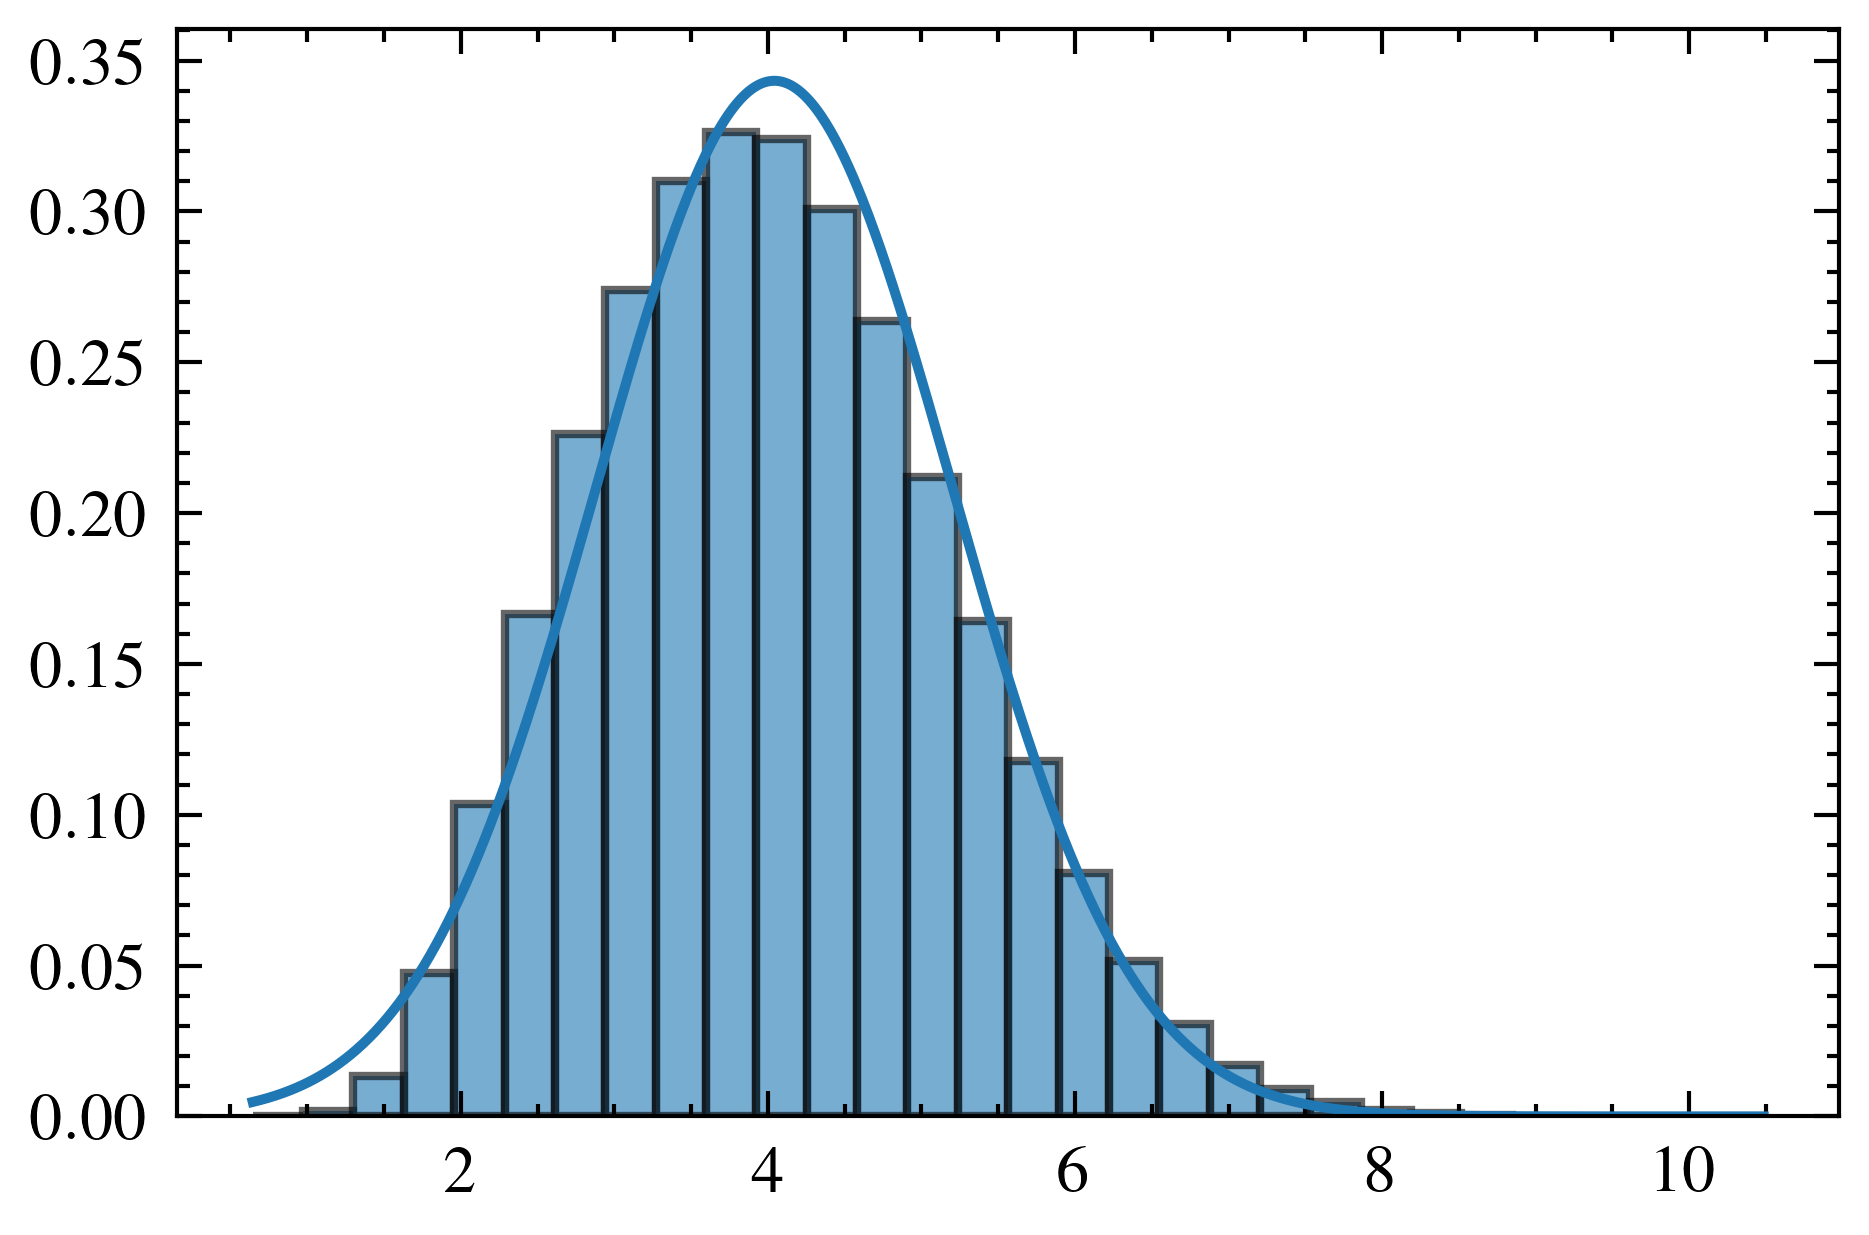

<Axes: >

In [9]:
smr_mc = smr_results["monte_carlo"]

from openpytea.plotting import plot_monte_carlo # We import the plotting function to visualize the Monte Carlo results

plot_monte_carlo(smr_mc)

### **Running The Other Plants and Comparing Results**

Now, the case study can be completed by running the TEA for the other two scenarios, namely methane pyrolysis and water electrolysis, and comparing their Monte Carlo results.

In [11]:
run_tea(equipment_input_path="input_configs/mp_equipment.json",
        plant_input_path="input_configs/mp_plant.json",
        analysis_input_path="input_configs/analysis-2.json",
        output_dir="outputs/mp_tea_results")

run_tea(equipment_input_path="input_configs/we_equipment.json",
        plant_input_path="input_configs/we_plant.json",
        analysis_input_path="input_configs/analysis-2.json",
        output_dir="outputs/we_tea_results")

Monte Carlo: 100%|██████████| 100/100 [03:42<00:00,  2.23s/it]


{'monte_carlo': {'name': 'Water Electrolysis',
  'metrics': {'LCOP': array([7.85479193, 9.39652569, 7.58160735, ..., 8.70676621, 5.97662754,
          8.55049821], shape=(1000000,)),
   'ROI': array([ 4.36282962,  1.19002137,  6.00763044, ...,  2.67863539,
          10.09203481, -3.40470079], shape=(1000000,)),
   'NPV': array([-2.80280104e+08, -4.03886243e+08, -2.86796318e+08, ...,
          -3.64619315e+08, -8.37804250e+07, -5.80631052e+08],
         shape=(1000000,)),
   'PBT': array([26.23066005, 58.69997558, 22.89108736, ..., 34.12050488,
          11.40109671,         nan], shape=(1000000,))},
  'inputs': {'Fixed capital factor': array([0.88355825, 1.02064449, 1.05403087, ..., 1.20539146, 0.69382427,
          1.08380185], shape=(1000000,)),
   'Fixed opex factor': array([0.99567369, 1.46272207, 0.86656327, ..., 0.71141161, 0.98951065,
          0.73426087], shape=(1000000,)),
   'Operator hourly rate': array([27.06189538, 42.46041052, 42.38571362, ..., 36.86522698,
          35.

<Figure size 1920x1320 with 0 Axes>

<Figure size 1920x1320 with 0 Axes>

We can use the function `load_results()` to retrieve our Monte Carlo results

In [13]:
mp_mc = load_results(filepath="outputs/mp_tea_results/Methane Pyrolysis_analysis_results.json")["monte_carlo"]
we_mc = load_results(filepath="outputs/we_tea_results/Water Electrolysis_analysis_results.json")["monte_carlo"]

Finally, we plot the Monte Carlo results all in the same figure using `plot_multiple_monte_carlo()` and getting the same results as in [Case Study 1](https://github.com/pbtamarona/OpenPyTEA/blob/main/examples/case_study_1.ipynb):

In [14]:
from openpytea.plotting import plot_multiple_monte_carlo

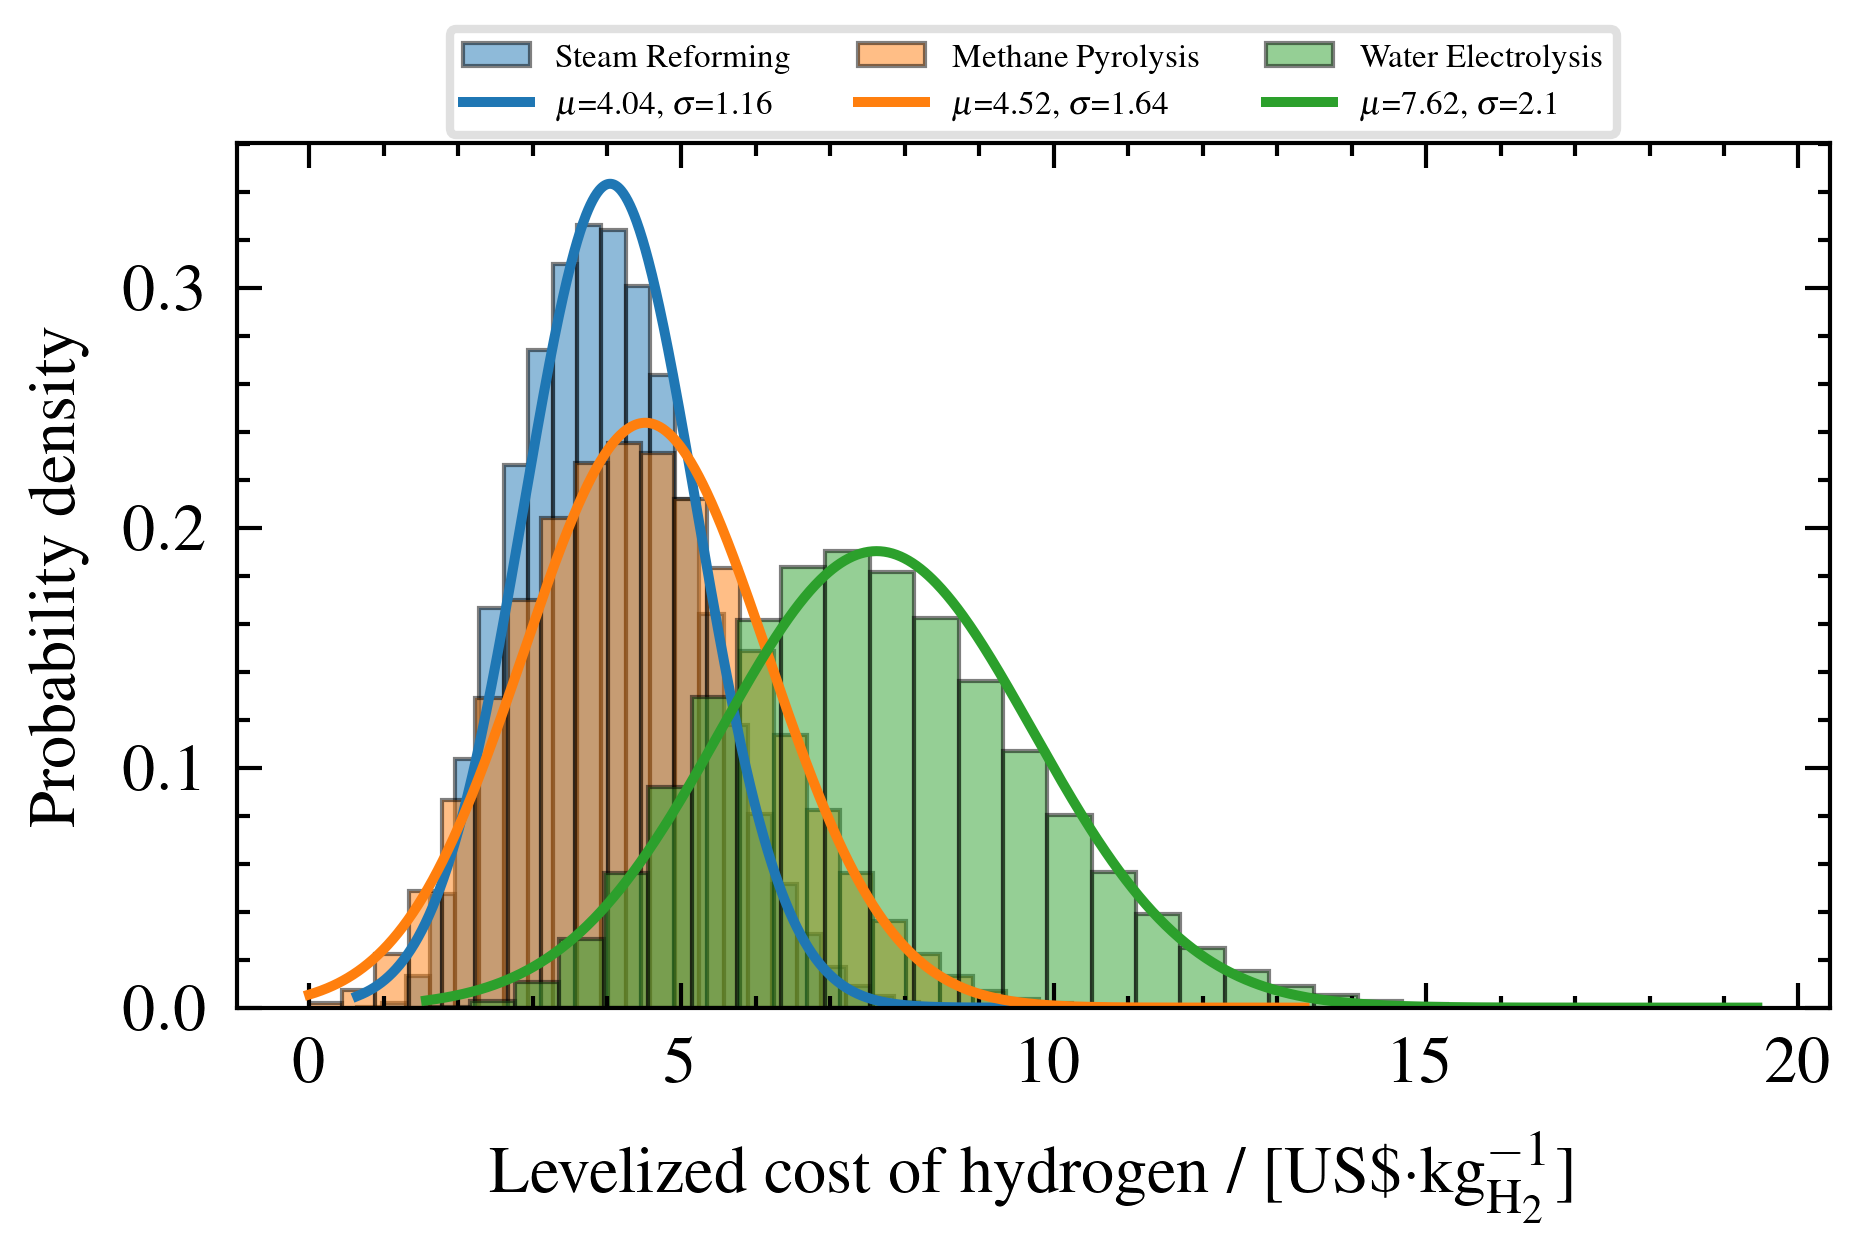

<Axes: xlabel='Levelized cost of hydrogen / [US\\$$\\cdot$kg$^{-1}_\\mathrm{H_2}$]', ylabel='Probability density'>

In [15]:
plot_multiple_monte_carlo(data_list=[smr_mc, mp_mc, we_mc], metric="LCOP", bins=30,
                          label=r'Levelized cost of hydrogen / [US\$$\cdot$kg$^{-1}_\mathrm{H_2}$]')